In [1]:
from typing import List
import re

import numpy as np
from matplotlib import pyplot as plt
import matplotlib

# include the path to the parent directory

import sys
sys.path.append('../../')

from mfgpflow.data_loader import StellarMassFunctions

# set a random number seed to reproducibility
np.random.seed(0)

In [2]:
import numpy as np
from mfgpflow.sb28_smf_loader import SMFDataLoaderSB28, counts_uncertainty_stacked   # <- your class file
from mfgpflow.sb28_smf_loader import SB28Paths, invert_standardizer
# from smf_uncertainty import counts_uncertainty_stacked  # <- your uncertainty fn

In [3]:
basedir = "../../data/SB28/ming-feng/"
#  The SMFs are obtained from the stellar mass of the galaxy catalog, 
# with each binned into 13 bins in the range [108.9, 1011.4] M⊙ which Leja et al. (2020) aims at.
log10M = np.array([
    8.15,  8.45,  8.75,  9.05,  9.35,  9.65, 9.95, 10.25, 10.55, 10.85, 11.15, 11.45, 11.75,
], dtype=np.float32)
snap_numbers = 73, 90

B = len(log10M)  # number of bins

paths = SB28Paths(basedir)
# paths.basedir = basedir

loader = SMFDataLoaderSB28(
    paths,
    log10M_centers=log10M,
    snapshots=snap_numbers,
    bin_edges=None,
    Lbox_mpc_over_h=25.0,
    y_transform="anscombe",
    standardize_X=True,
    standardize_Y=False,
    standardize_Y_128=False,
    standradize_Y_256=True,
)

## Visualize the SB28


Text(0.5, 0.98, 'SMF with uncertainties (SB28, snap 73)')

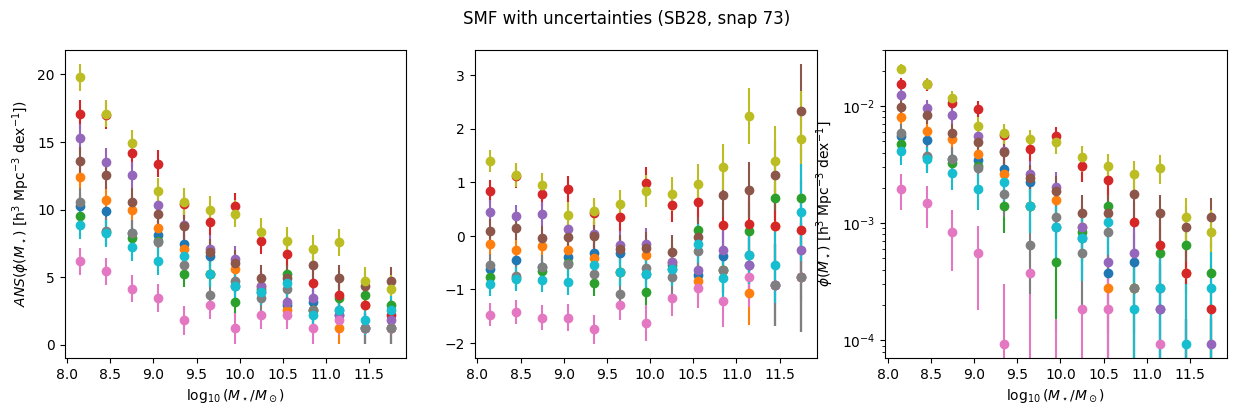

In [4]:
# Snap 73
## Plotting multiple simulations
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for sim_idx in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    ax[0].errorbar(
        log10M,
        invert_standardizer(loader.Y256, loader.Y256_stats)[sim_idx, :len(log10M)],
        yerr=loader.sigma_A256[sim_idx, :len(log10M)],
        fmt='o',
    )

    ax[1].errorbar(
        log10M,
        loader.Y256[sim_idx, :len(log10M)],
        yerr=loader.sigma_A256_standardized[sim_idx, :len(log10M)],
        fmt='o',
    )
    ax[2].errorbar(
        log10M,
        loader.PHI256[sim_idx, :len(log10M)],
        yerr=loader.sigma_phi256_total[sim_idx, :len(log10M)],
        fmt='o',
    )

ax[0].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[0].set_ylabel(r"$ANS(\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$])")
ax[2].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[2].set_ylabel(r"$\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
ax[2].set_yscale('log')

fig.suptitle("SMF with uncertainties (SB28, snap 73)")
# plt.legend()

Text(0.5, 0.98, 'SMF with uncertainties (SB28, snap 73, 512)')

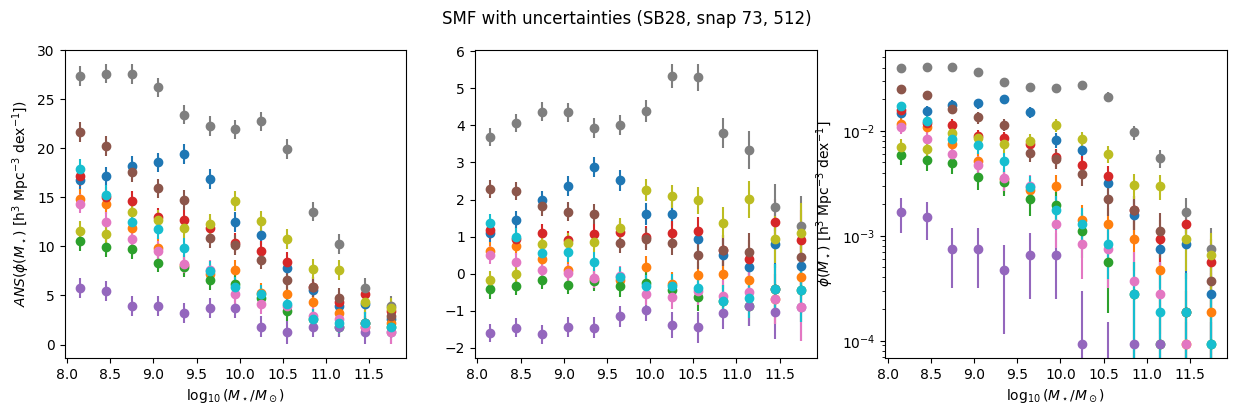

In [5]:
# Snap 73, 512
## Plotting multiple simulations
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for sim_idx in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    ax[0].errorbar(
        log10M,
        invert_standardizer(loader.Y512, loader.Y512_stats)[sim_idx, len(log10M):],
        yerr=loader.sigma_A512[sim_idx, len(log10M):],
        fmt='o',
    )

    ax[1].errorbar(
        log10M,
        loader.Y512[sim_idx, len(log10M):],
        yerr=loader.sigma_A512_standardized[sim_idx, len(log10M):],
        fmt='o',
    )
    ax[2].errorbar(
        log10M,
        loader.PHI512[sim_idx, len(log10M):],
        yerr=loader.sigma_phi512_total[sim_idx, len(log10M):],
        fmt='o',
    )

ax[0].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[0].set_ylabel(r"$ANS(\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$])")
ax[2].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[2].set_ylabel(r"$\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
ax[2].set_yscale('log')


fig.suptitle("SMF with uncertainties (SB28, snap 73, 512)")
# plt.legend()

## Input space

There are actually logFlag for some dimension, I should make sure the input are linear~

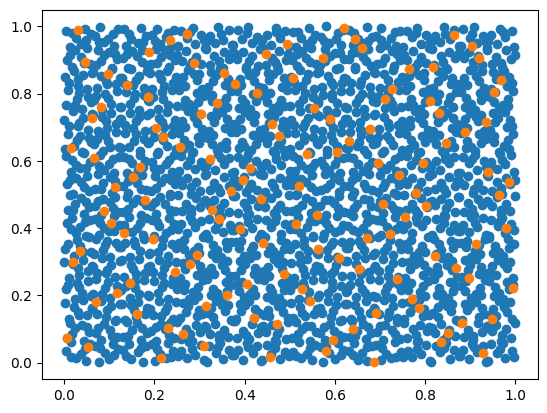

In [6]:
plt.scatter(loader.X256[:, 0], loader.X256[:, 2])
plt.scatter(loader.X512[:, 0], loader.X512[:, 2])

## LOO GP training:

256 -> 512

In [7]:
from mfgpflow.linear_svgp import LatentMFCoregionalizationSVGP
import numpy as np
import gpflow
import tensorflow as tf
from sklearn.cluster import KMeans

In [10]:
loader.X512.shape, loader.Y512.shape, loader.X256.shape, loader.Y256.shape, loader.X128.shape, loader.Y128.shape

((128, 28), (32, 26), (2048, 28), (2048, 26), (2048, 28), (2048, 26))

In [10]:
import numpy as np

def suggest_L_from_Y(Y, thresh=0.95):
    """
    Y: (N, P) targets (stacked snapshots as columns).
    Returns smallest L explaining 'thresh' fraction of variance.
    """
    Yc = Y - Y.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Yc, full_matrices=False)  # S: singular values
    expl = (S**2) / np.sum(S**2)
    cum = np.cumsum(expl)
    L = int(np.searchsorted(cum, thresh) + 1)
    return L, expl, cum

# Example:
L_suggested, expl, cum = suggest_L_from_Y(loader.Y256)  # Y_train shape (N, 26)
print("Suggested L:", L_suggested)

# Example:
L_suggested, expl, cum = suggest_L_from_Y(loader.Y512)  # Y_train shape (N, 26)
print("Suggested L:", L_suggested)

Suggested L: 5
Suggested L: 4


In [ ]:
# Leave-one-out (LOO) experiment: 256 -> 512

# Define a function to prepare emulator
def prep_emulator(
        loader : StellarMassFunctions,
        test_ind : int,
        num_latents: int,
        num_inducing: int,
        frac_HF_Z: float,
        heterosed: bool,
        vector_variance: bool,
    ):
    """
    Prepares training and test data for the emulator.
    """
    X512 = loader.X512[:32] # TODO: only 32 samples are available for now

    # Leave one out trick
    mask = np.arange(len(X512)) != test_ind

    X_LF, Y_LF = loader.X256, loader.Y256 # LF Data (2048, 28) -> (2048, 26)
    X_HF, Y_HF = X512[mask], loader.Y512[mask, :] # HF Data (24, 28) → (24, 26)

    # test data: shape (8, 28) -> (8, 26)
    X_test_HF, Y_test_HF = X512[~mask, :], loader.Y512[~mask, :]

    # Only one redshift snapshot is used for training for now
    # TODO: Use multiple snapshots for training
    Y_LF = Y_LF[:, :len(loader.log10M)]  # Ensure Y_LF has 13 outputs
    Y_HF = Y_HF[:, :len(loader.log10M)]  # Ensure Y_HF has 13 outputs
    # Noise variance
    Var_LF = loader.sigma_A256_standardized[:, :len(loader.log10M)] ** 2  # (2048, 13)
    Var_HF = loader.sigma_A512_standardized[mask, :len(loader.log10M)] ** 2  # (24, 13)
    # Ensure Y_test_HF has 13 outputs
    Y_test_HF = Y_test_HF[:, :len(loader.log10M)]  # Ensure Y_test_HF has 13 outputs
    Var_test_HF = loader.sigma_A512_standardized[~mask, :len(loader.log10M)] ** 2  # (8, 13)

    # 🔹 2️⃣ Prepare Training Data
    n_LF, n_HF = X_LF.shape[0], X_HF.shape[0]  # Number of points
    output_dim = Y_LF.shape[1]

    # ✅ Append fidelity indicators (0 for LF, 1 for HF)
    X_LF_aug = np.hstack([X_LF, np.zeros((n_LF, 1))])  # LF data with fidelity=0
    X_HF_aug = np.hstack([X_HF, np.ones((n_HF, 1))])   # HF data with fidelity=1

    # ✅ Combine datasets
    X_train = np.vstack([X_LF_aug, X_HF_aug])  # Shape: (2072, 29)
    Y_train = np.vstack([Y_LF, Y_HF])  # Shape: (2072, 26)
    # noise variance
    Var_train = np.vstack([Var_LF, Var_HF])  # Shape: (2072, 13)

    # 🔹 3️⃣ Define Multi-Fidelity GP Model
    # ✅ Define base kernels for LF and HF discrepancy
    D_feat = X_train.shape[1] - 1  # drop fidelity flag

    # Shared physics (appears in LL, LH, HH via ρ)
    kL_long  = gpflow.kernels.Matern52(lengthscales=np.ones(D_feat),      variance=1.0)
    # kL_short = gpflow.kernels.Matern32(lengthscales=0.12*np.ones(D_feat), variance=0.3)
    # RationalQuadratic is more flexible than Matern32
    kL_short = gpflow.kernels.RationalQuadratic(lengthscales=np.ones(D_feat),
                                           variance=0.5, alpha=0.8)  # alpha ~ 0.3–1.5
    kernel_L = kL_long + kL_short

    # HF‑only discrepancy (only K_HH); lighter to avoid confounding
    kD_main  = gpflow.kernels.Matern52(lengthscales=np.ones(D_feat),      variance=0.5)
    kD_short = gpflow.kernels.Matern32(lengthscales=0.20*np.ones(D_feat), variance=0.08)
    kernel_delta = kD_main + kD_short

    # original kernels
    # kernel_L = gpflow.kernels.Matern52(lengthscales=np.ones(param_dim), variance=1.0)
    # kernel_delta = gpflow.kernels.Matern52(lengthscales=np.ones(param_dim), variance=1.0)

    # # ✅ Optimize Inducing Points using K-Means Clustering
    # kmeans = KMeans(n_clusters=num_inducing, random_state=42).fit(X_train)
    # Z_init = kmeans.cluster_centers_

    # Vector variance initialization, such that each output has its own noise variance
    if vector_variance:
        variance = np.var(Y_train, axis=0, keepdims=True).flatten() * 0.1 if not heterosed else np.var(Y_train, axis=0, keepdims=True).flatten() * 0.01
    else:
        variance = np.array([1.0], dtype=np.float64) if not heterosed else np.array([0.1], dtype=np.float64)

    # Z_init center more on HF region
    M = num_inducing
    M_LF = int((1 - frac_HF_Z)*M)
    M_HF = M - M_LF

    Z_LF = KMeans(n_clusters=M_LF, random_state=42).fit(X_LF_aug).cluster_centers_
    Z_HF = KMeans(n_clusters=M_HF, random_state=42).fit(X_HF_aug).cluster_centers_
    Z_init = np.vstack([Z_LF, Z_HF])
    # inducing_variable = SharedIndependentInducingVariables(InducingPoints(Z_init))

    # ✅ Initialize the Latent Multi-Fidelity Coregionalization SVGP model
    mf_gp = LatentMFCoregionalizationSVGP(
        X_train, Y_train,
        kernel_L, kernel_delta,
        num_outputs=output_dim, num_latents=num_latents, num_inducing=num_inducing,
        heterosed=True,  # Heteroscedastic noise model,
        variance=variance,  # Initial noise variance
        Z_init=Z_init
    )

    ########## W Initialization ##########
    # B) W with global + local + (near) diagonal columns
    # If you push L > P, make the extra columns of W_local and W_diag narrower /
    #  more sparse so they capture non‑smooth, bin‑specific effects rather than duplicating global structure.

    def windowed_W(P, centers, width_bins):
        idx = np.arange(P)[:, None]
        cen = np.array(centers)[None, :]
        W = np.exp(-0.5 * ((idx - cen) / width_bins) ** 2)
        W /= np.linalg.norm(W, axis=0, keepdims=True) + 1e-8
        return W

    P = output_dim
    L_global = 4                                # smooth bulk structure
    L_local  = 3                                # localized columns
    L_diag   = num_latents - L_global - L_local # bin-specific columns
    L        = L_global + L_local + L_diag

    # Global: PCA on (centered) Y
    Yc = Y_train - Y_train.mean(axis=0, keepdims=True)
    _, _, Vt = np.linalg.svd(Yc, full_matrices=False)
    W_global = Vt[:L_global].T                      # (P, L_global)

    # Local: Gaussian windows across bins
    centers  = np.linspace(0, P-1, L_local)
    W_local  = windowed_W(P, centers, width_bins=1.5)

    # (Near) diagonal: give a couple bins one‑hot columns
    W_diag = np.zeros((P, L_diag))
    hot_bins = np.linspace(0, P-1, L_diag, dtype=int)
    # hot_bins = np.linspace(0, L_diag - 1, L_diag, dtype=int)
    for j, b in enumerate(hot_bins):
        W_diag[b, j] = 1.0

    W_init = np.hstack([W_global, W_local, W_diag]).astype(np.float64) * 0.5
    mf_gp.kernel.W.assign(W_init)   # works because top kernel is still LinearCoregionalization

    import time
    start = time.time()
    if heterosed:
        print("Initial noise variances (heteroscedastic):", mf_gp.likelihood.variance.numpy())
        # 🔹 4️⃣ Train the Model with Adaptive Learning Rate
        mf_gp.optimize(
            (X_train, np.concatenate([Y_train, Var_train], axis=1)),  # Concatenate Y and Var for heteroscedastic case
            max_iters=3000,  # Reduce training iterations
            initial_lr=0.01,  # Lower learning rate for stability
            unfix_noise_after=500,  # Delay unfixing noise variance
            # decay_lr=True  # Enable learning rate decay
        )

    else:
        print("Initial noise variance (homoscedastic):", mf_gp.likelihood.variance.numpy())
        # 🔹 4️⃣ Train the Model with Adaptive Learning Rate
        mf_gp.optimize(
            (X_train, Y_train),
            max_iters=3000,  # Reduce training iterations
            initial_lr=0.01,  # Lower learning rate for stability
            unfix_noise_after=500,  # Delay unfixing noise variance
            # decay_lr=True  # Enable learning rate decay
        )

    print(f"Training Time: {time.time() - start:.2f} seconds")

    # save the model
    mf_gp.save_model(f"models/loo_mf_gp_256_512_test{test_ind}_L{num_latents}_M{num_inducing}_frac{frac_HF_Z}_heterosed{heterosed}_vecvar{vector_variance}.zip")

    return mf_gp, X_train, Y_train, Var_train, X_test_HF, Y_test_HF, Var_test_HF

Run the loo -> store the models into both pkl and list

In [ ]:
# parameter dim: 28; output dim: 26 (reduced to 13 bins per snapshot)
param_dim = loader.X512.shape[1]  # 28 input parameters
# test_ind = 0
num_latents = 9     # Reduce latent GPs to match HF sparsity
num_inducing = 192  # Reduce inducing points to prevent overfitting
frac_HF_Z = 0.45  # fraction of inducing points in HF region
heterosed = True
vector_variance = True

models = []  # to store the models

for test_ind in range(32):
    mf_gp, X_train, Y_train, Var_train, X_test_HF, Y_test_HF, Var_test_HF = prep_emulator(
        loader,
        test_ind,
        num_latents,
        num_inducing,
        frac_HF_Z,
        heterosed,
        vector_variance,
    )
    # save the model into a list
    models.append(mf_gp)
    print(f"Model for test index {test_ind} prepared and saved.")

Initial noise variances (heteroscedastic): [0.01014197 0.01011641 0.01009518 0.01009633 0.01010833 0.010079
 0.01008962 0.0101044  0.01014726 0.01008704 0.01005657 0.01003065
 0.00999517]
🔹 Iteration 0: ELBO = 154046.21894288913
🔹 Iteration 100: ELBO = 60864.747214982315
🔹 Iteration 200: ELBO = 33671.54381886597
🔹 Iteration 300: ELBO = 26393.123290982614
🔹 Iteration 400: ELBO = 23125.367756278356
🔹 Iteration 500: ELBO = 21189.878659458336
🔹 Iteration 600: ELBO = 16022.258767338037
🔹 Iteration 700: ELBO = 15639.27567533132
🔹 Iteration 800: ELBO = 15332.840871818113
🔹 Iteration 900: ELBO = 14994.013687244857
🔹 Iteration 1000: ELBO = 14714.41050351839
🔹 Iteration 1100: ELBO = 14539.93382674305
🔹 Iteration 1200: ELBO = 14415.52176159691
🔹 Iteration 1300: ELBO = 14292.926816650966
🔹 Iteration 1400: ELBO = 14198.349502067684
🔹 Iteration 1500: ELBO = 14113.036430542574
🔹 Iteration 1600: ELBO = 14033.00260486741
🔹 Iteration 1700: ELBO = 13959.399282995388
🔹 Iteration 1800: ELBO = 13895.7178310

Loss history

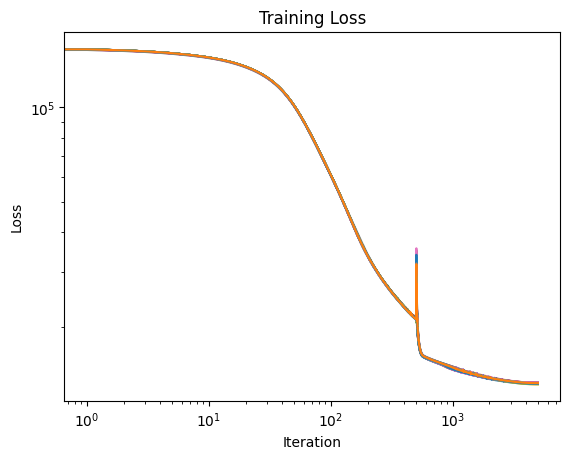

In [24]:
for i in range(32):
    plt.plot(models[i].loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.yscale('log')
    plt.xscale('log')
    plt.title("Training Loss")
    # plt.show()

## Testing code

In [27]:
X512 = loader.X512[:32] # TODO: only 32 samples are available for now

X_LF, Y_LF = loader.X256, loader.Y256 # LF Data (2048, 28) -> (2048, 26)
X_HF, Y_HF = X512, loader.Y512        # HF Data (24, 28) → (24, 26)

# Only one redshift snapshot is used for training for now
# TODO: Use multiple snapshots for training
Y_LF = Y_LF[:, :len(loader.log10M)]  # Ensure Y_LF has 13 outputs
Y_HF = Y_HF[:, :len(loader.log10M)]  # Ensure Y_HF has 13 outputs
# Noise variance
Var_LF = loader.sigma_A256_standardized[:, :len(loader.log10M)] ** 2  # (2048, 13)
Var_HF = loader.sigma_A512_standardized[:, :len(loader.log10M)] ** 2  # (24, 13)

# 🔹 2️⃣ Prepare Training Data
n_LF, n_HF = X_LF.shape[0], X_HF.shape[0]  # Number of points
output_dim = Y_LF.shape[1]

# ✅ Append fidelity indicators (0 for LF, 1 for HF)
X_LF_aug = np.hstack([X_LF, np.zeros((n_LF, 1))])  # LF data with fidelity=0
X_HF_aug = np.hstack([X_HF, np.ones((n_HF, 1))])   # HF data with fidelity=1

In [28]:
# Leave-one-out test index
for test_ind in range(32):
    mask = np.arange(len(X512)) != test_ind
    mf_gp = models[test_ind]
    X_test_HF, Y_test_HF = X512[~mask, :], loader.Y512[~mask, :]
    Var_test_HF = loader.sigma_A512_standardized[~mask, :len(loader.log10M)] ** 2  # (8, 13)
    Y_test_HF = Y_test_HF[:, :len(loader.log10M)]  # Ensure Y_test_HF has 13 outputs
    print(f"Making predictions for test index {test_ind}...")

    # 🔹 5️⃣ Make Predictions on HF Test Set
    num_test_points = X_test_HF.shape[0]
    X_test_HF_aug = np.hstack([X_test_HF, np.ones((num_test_points, 1))])  # Append fidelity indicators
    mean_pred, var_pred = mf_gp.predict_f(X_test_HF_aug)

    # 🔹 6️⃣ Compute Residuals
    residuals = mean_pred.numpy() - Y_test_HF  # Shape: (10, 49)

    # ✅ Print summary
    print(f"🔍 Final Residuals: {residuals.mean():.4f} ± {residuals.std():.4f}")
    print(f"✅ Model trained and predictions completed!")

    # # ✅ Check Learned W Matrix
    # print("🔍 Final Learned W Matrix:")
    # print(mf_gp.kernel.W.numpy())

    # # ✅ Check Noise Variance
    # print(f"🔍 Learned noise variance: {mf_gp.likelihood.variance.numpy()}")

    # ✅ Evaluate Test Performance
    from sklearn.metrics import mean_squared_error
    mse = mean_squared_error(Y_test_HF, mean_pred.numpy())
    print(f"🔍 HF Prediction MSE: {mse:.4f}")

    # LF train points
    mean_pred_LF, var_pred_LF = mf_gp.predict_f(X_LF_aug)
    # HF train points
    mean_pred_HF, var_pred_HF = mf_gp.predict_f(X_HF_aug)
    # Evaluate training performance
    mse_LF = mean_squared_error(Y_LF, mean_pred_LF.numpy())
    mse_HF = mean_squared_error(Y_HF, mean_pred_HF.numpy())
    print(f"🔍 LF Train MSE: {mse_LF:.4f}")
    print(f"🔍 HF Train MSE: {mse_HF:.4f}")

Making predictions for test index 0...
🔍 Final Residuals: 0.5388 ± 0.4236
✅ Model trained and predictions completed!
🔍 HF Prediction MSE: 0.4698
🔍 LF Train MSE: 0.1161
🔍 HF Train MSE: 0.1420
Making predictions for test index 1...
🔍 Final Residuals: 0.1387 ± 0.2402
✅ Model trained and predictions completed!
🔍 HF Prediction MSE: 0.0769
🔍 LF Train MSE: 0.1148
🔍 HF Train MSE: 0.1344
Making predictions for test index 2...
🔍 Final Residuals: -0.0161 ± 0.2126
✅ Model trained and predictions completed!
🔍 HF Prediction MSE: 0.0455
🔍 LF Train MSE: 0.1163
🔍 HF Train MSE: 0.1229
Making predictions for test index 3...
🔍 Final Residuals: -0.6140 ± 0.3166
✅ Model trained and predictions completed!
🔍 HF Prediction MSE: 0.4772
🔍 LF Train MSE: 0.1161
🔍 HF Train MSE: 0.1480
Making predictions for test index 4...
🔍 Final Residuals: -0.1358 ± 0.2214
✅ Model trained and predictions completed!
🔍 HF Prediction MSE: 0.0675
🔍 LF Train MSE: 0.1160
🔍 HF Train MSE: 0.1306
Making predictions for test index 5...
🔍 F

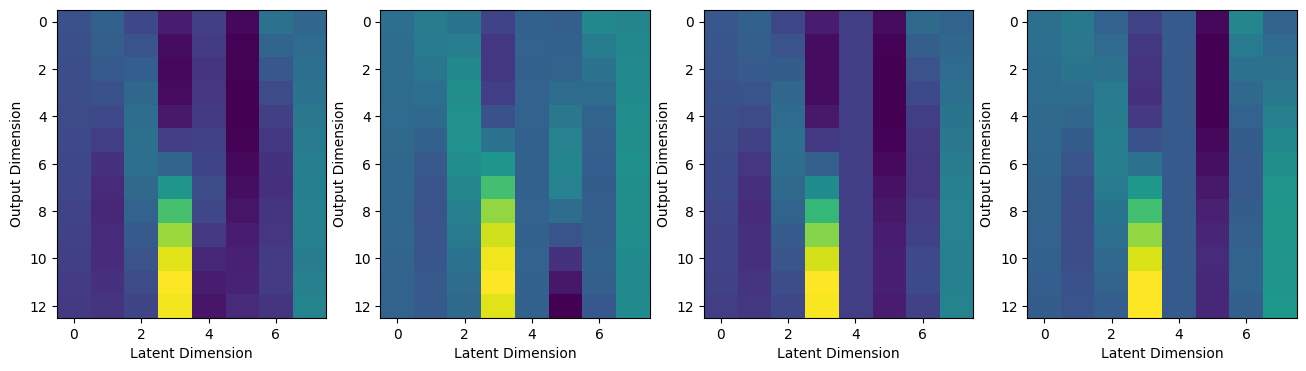

In [33]:
# Learned W Matrix
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
# plot the W matrix
# ax[0].imshow(W_init, aspect="auto")
for test_ind in range(4):
    mf_gp = models[test_ind]
    ax[test_ind].imshow(mf_gp.kernel.W.numpy(), aspect="auto")
    # ax[0].set_colorbar()
    ax[test_ind].set_ylabel("Output Dimension")
    ax[test_ind].set_xlabel("Latent Dimension")


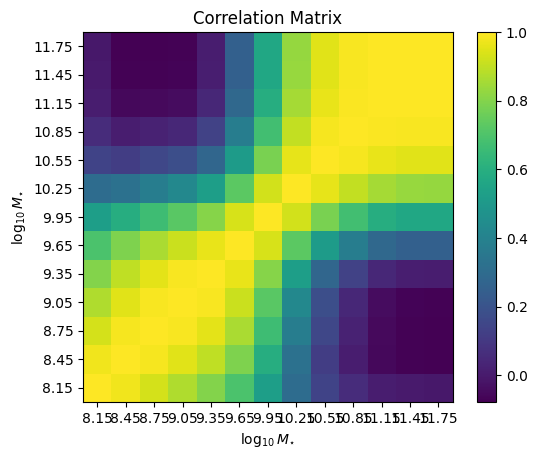

In [32]:
# Learned W Matrix
# plot the W matrix
# plt.imshow(mf_gp.kernel.W.numpy(), aspect="auto")
# plt.colorbar()
# plt.title("Learned W Matrix")
# plt.ylabel("Output Dimension")
# plt.xlabel("Latent Dimension")

K = mf_gp.kernel.W.numpy() @ mf_gp.kernel.W.numpy().T
# make it correlation matrix
D = np.diag(1/np.sqrt(np.diag(K)))
K = D @ K @ D

# Make the lower left corner to be origin of the plot
plt.imshow(K, cmap="viridis", origin="lower", )
plt.colorbar()
# I want the log mass bins to be ticks and labels
plt.xticks(range(len(loader.log10M)), loader.log10M)
plt.yticks(range(len(loader.log10M)), loader.log10M)
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$\log_{10}M_{\star}$")
plt.title("Correlation Matrix")
plt.show()


## Make LOO predictions

In [37]:
# Leave-one-out test index
mean_pred = []
var_pred = []
for test_ind in range(32):
    mask = np.arange(len(X512)) != test_ind
    mf_gp = models[test_ind]
    X_test_HF, Y_test_HF = X512[~mask, :], loader.Y512[~mask, :]
    Var_test_HF = loader.sigma_A512_standardized[~mask, :len(loader.log10M)] ** 2  # (8, 13)
    Y_test_HF = Y_test_HF[:, :len(loader.log10M)]  # Ensure Y_test_HF has 13 outputs
    print(f"Making predictions for test index {test_ind}...")

    # 🔹 5️⃣ Make Predictions on HF Test Set
    num_test_points = X_test_HF.shape[0]
    X_test_HF_aug = np.hstack([X_test_HF, np.ones((num_test_points, 1))])  # Append fidelity indicators
    m_pred, v_pred = mf_gp.predict_f(X_test_HF_aug)
    mean_pred.append(m_pred.numpy())
    var_pred.append(v_pred.numpy())
mean_pred = np.vstack(mean_pred)
var_pred = np.vstack(var_pred)
mean_pred.shape, var_pred.shape

Making predictions for test index 0...
Making predictions for test index 1...
Making predictions for test index 2...
Making predictions for test index 3...
Making predictions for test index 4...
Making predictions for test index 5...
Making predictions for test index 6...
Making predictions for test index 7...
Making predictions for test index 8...
Making predictions for test index 9...
Making predictions for test index 10...
Making predictions for test index 11...
Making predictions for test index 12...
Making predictions for test index 13...
Making predictions for test index 14...
Making predictions for test index 15...
Making predictions for test index 16...
Making predictions for test index 17...
Making predictions for test index 18...
Making predictions for test index 19...
Making predictions for test index 20...
Making predictions for test index 21...
Making predictions for test index 22...
Making predictions for test index 23...
Making predictions for test index 24...
Making pre

((32, 13), (32, 13))

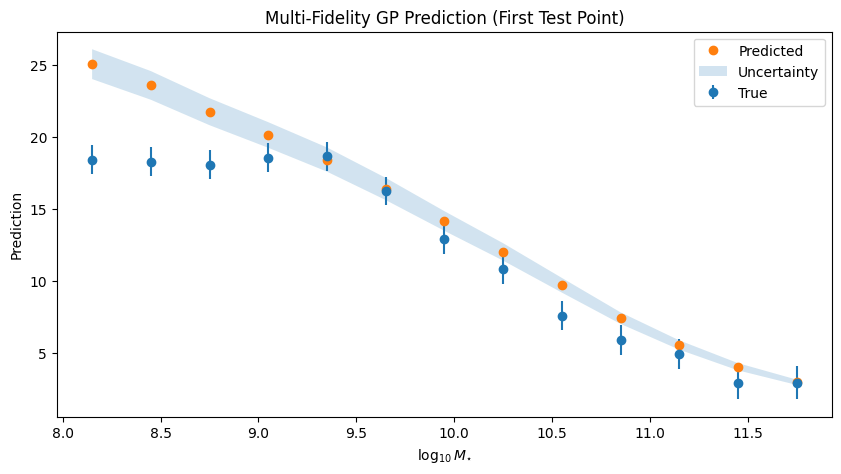

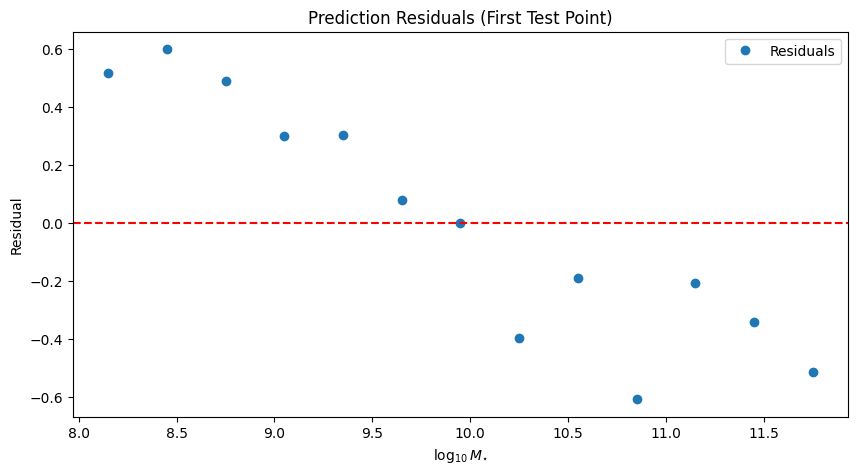

In [ ]:
# Prediction
# 🔹 7️⃣ Plot Predictions vs Ground Truth
import matplotlib.pyplot as plt

stats = {"mu" : loader.Y256_stats["mu"][:len(loader.log10M)], "sd": loader.Y256_stats["sd"][:len(loader.log10M)]}

plt.figure(figsize=(10, 5))
plt.errorbar(loader.log10M,
             invert_standardizer(Y_HF[0], stats),
             yerr=loader.sigma_A256[0, :len(loader.log10M)],
             fmt='o', label="HF True")

plt.plot(loader.log10M,
         invert_standardizer(mean_pred[0], stats),
         ls="",marker="o", label="Predicted")
plt.fill_between(
    loader.log10M,
    invert_standardizer((mean_pred[0] - np.sqrt(var_pred[0])), stats),
    invert_standardizer((mean_pred[0] + np.sqrt(var_pred[0])), stats),
    alpha=0.2, label="Uncertainty"
)

plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel("Prediction")
plt.legend()
plt.title("Multi-Fidelity GP Prediction (First Test Point)")
plt.show()

# 🔹 8️⃣ Residual Plot
plt.figure(figsize=(10, 5))
plt.plot(loader.log10M, residuals[0], marker="o", ls="", label="Residuals")
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel("Residual")
plt.legend()
plt.title("Prediction Residuals (First Test Point)")
plt.show()

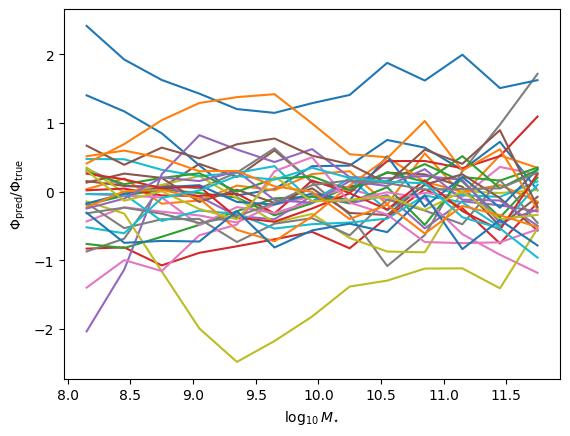

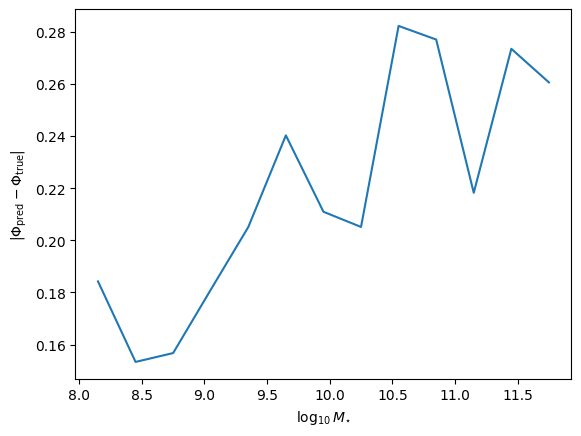

In [39]:
# plt.plot(loader.log10M, (mean_pred - Y_test_HF).numpy().T);
plt.plot(loader.log10M, (mean_pred - Y_HF).T);
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$\Phi_{\mathrm{pred}}/\Phi_{\mathrm{true}}$")
plt.show()
# absolute error
relative_error = np.abs(invert_standardizer(mean_pred, stats) / invert_standardizer(Y_HF, stats) - 1)
plt.plot(loader.log10M, relative_error.mean(axis=0));
# plt.fill_between(loader.log10M, relative_error.min(axis=0), relative_error.max(axis=0), alpha=0.3)
# plt.plot(relative_error.mean(axis=0));
# plt.fill_between(relative_error.min(axis=0), relative_error.max(axis=0), alpha=0.3)
# plt.ylim(0, 0.5)
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$|\Phi_{\mathrm{pred}}-\Phi_{\mathrm{true}}|$")
plt.show()

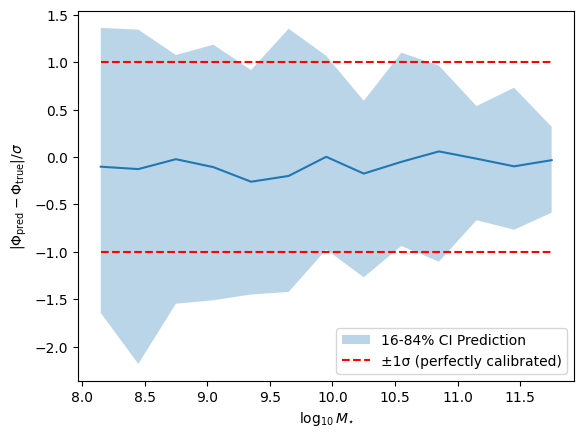

In [40]:
# Difference plot
relative_error = ((invert_standardizer(mean_pred, stats) - invert_standardizer(Y_HF, stats))
                  ) / (np.sqrt(Var_HF + var_pred) * stats["sd"])
plt.plot(loader.log10M, relative_error.mean(axis=0));
# 16 and 84 percentiles
q16, q50, q84 = np.percentile(relative_error, [16, 50, 84], axis=0)
plt.fill_between(loader.log10M, q16, q84, alpha=0.3, label="16-84% CI Prediction")
# plt.plot(relative_error.mean(axis=0));
# plt.fill_between(relative_error.min(axis=0), relative_error.max(axis=0), alpha=0.3)
# plt.ylim(0, 0.5)
plt.hlines([-1, 1], min(loader.log10M), max(loader.log10M), color='r', ls='--', label="±1σ (perfectly calibrated)")
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$|\Phi_{\mathrm{pred}}-\Phi_{\mathrm{true}}| / \sigma$")
plt.legend()
plt.show()

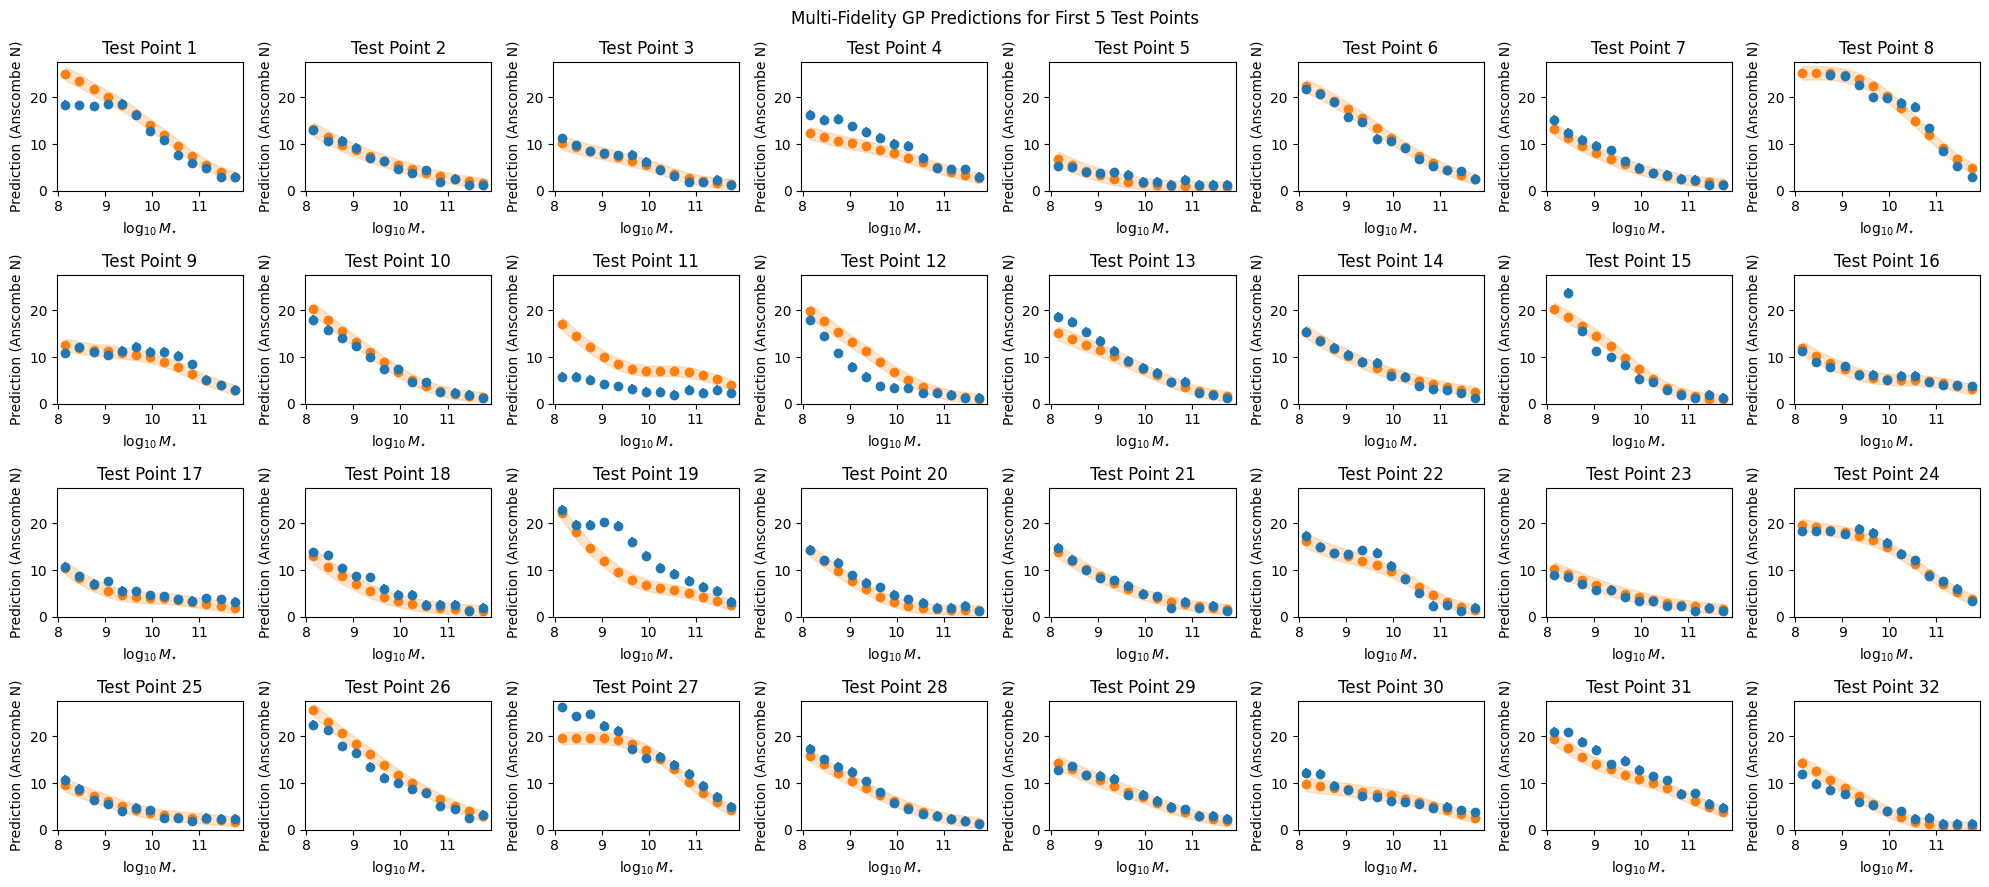

In [42]:
# a few predictions
fig, ax = plt.subplots(4, 8, figsize=(20, 9))

ax = ax.flatten()
for i, test_ind in enumerate(range(0, 32)):
    # test_ind = 0  # Change this to select different test points
    ax[i].errorbar(
        loader.log10M, 
        invert_standardizer(Y_HF[test_ind], stats),
        yerr=loader.sigma_A512[test_ind, :len(loader.log10M)],
        fmt='o', label="True")
    ax[i].plot(loader.log10M, invert_standardizer(mean_pred[test_ind], stats), ls="",marker="o", label="Predicted")
    ax[i].fill_between(
        loader.log10M,
        invert_standardizer((mean_pred[test_ind] - np.sqrt(var_pred[test_ind] + loader.sigma_A512_standardized.mean(axis=0)[:len(loader.log10M)]**2 )), stats),
        invert_standardizer((mean_pred[test_ind] + np.sqrt(var_pred[test_ind] +  + loader.sigma_A512_standardized.mean(axis=0)[:len(loader.log10M)]**2 )), stats),
        alpha=0.2, label="Uncertainty", color='C1'
    )
    

    ax[i].set_xlabel(r"$\log_{10}M_{\star}$")
    ax[i].set_ylabel("Prediction (Anscombe N)")
    ax[i].set_title(f"Test Point {test_ind + 1}")

    ax[i].set_ylim(0, 27.5)
plt.suptitle("Multi-Fidelity GP Predictions for First 5 Test Points")
plt.tight_layout()



In [44]:
from mfgpflow.sb28_smf_loader import anscombe_to_phi

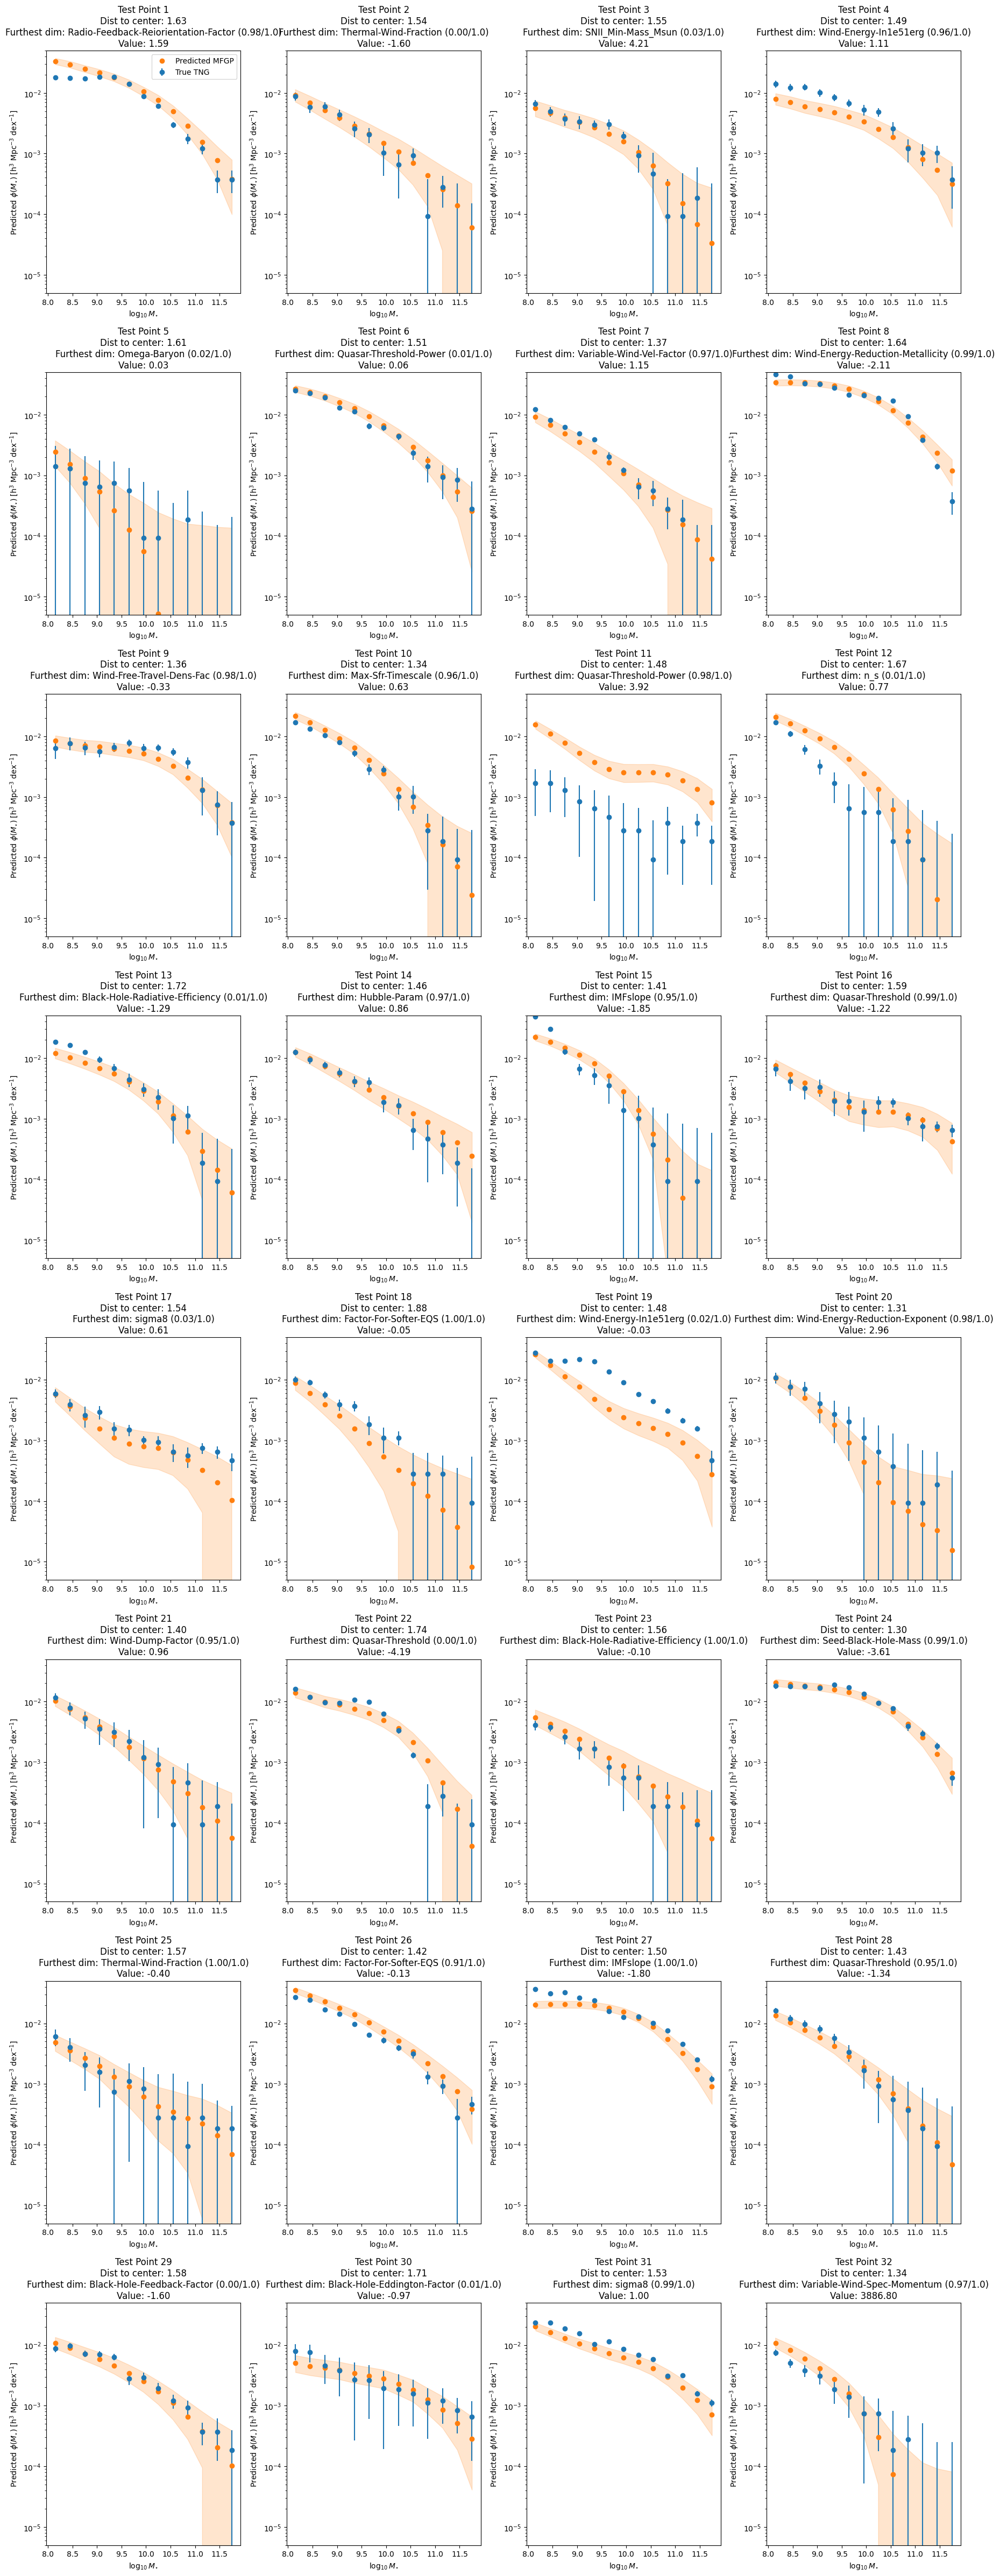

In [77]:
# a few predictions: Phi space
fig, ax = plt.subplots(8, 4, figsize=(18,48))

ax = ax.flatten()
for i, test_ind in enumerate(range(0, 32)):
    # test_ind = 0  # Change this to select different test points
    phiA, VarA = anscombe_to_phi(invert_standardizer(Y_HF[test_ind], stats),
                    loader.sigma_A512[test_ind, :len(loader.log10M)],
                    dlog10M=loader.dlog10M,
                    Lbox=loader.Lbox
                    )
    ax[i].errorbar(
        loader.log10M, phiA,
        yerr=loader.sigma_phi256_total[test_ind, :len(loader.log10M)],
        fmt='o', label="True TNG")
    phiA, VarA = anscombe_to_phi(invert_standardizer(mean_pred[test_ind], stats), 
                                 var_pred[test_ind] + loader.sigma_A512_standardized.mean(axis=0)[:len(loader.log10M)]**2,
                                 dlog10M=loader.dlog10M,
                                 Lbox=loader.Lbox
                                 )
    ax[i].plot(
        loader.log10M, phiA, ls="",marker="o", label="Predicted MFGP"
    )
    lowerA, _ = anscombe_to_phi(
        invert_standardizer((mean_pred[test_ind] - np.sqrt(var_pred[test_ind] + loader.sigma_A512_standardized.mean(axis=0)[:len(loader.log10M)]**2 )), stats),
        var_pred[test_ind] + loader.sigma_A512_standardized.mean(axis=0)[:len(loader.log10M)]**2,
        dlog10M=loader.dlog10M,
        Lbox=loader.Lbox
    )
    higherA, _ = anscombe_to_phi(
        invert_standardizer((mean_pred[test_ind] + np.sqrt(var_pred[test_ind] + loader.sigma_A512_standardized.mean(axis=0)[:len(loader.log10M)]**2 )), stats),
        var_pred[test_ind] + loader.sigma_A512_standardized.mean(axis=0)[:len(loader.log10M)]**2,
        dlog10M=loader.dlog10M,
        Lbox=loader.Lbox
    )   
    ax[i].fill_between(
        loader.log10M,
        lowerA,
        higherA,
        alpha=0.2, #label="Uncertainty",
        color='C1'
    )
    

    ax[i].set_xlabel(r"$\log_{10}M_{\star}$")
    ax[i].set_ylabel("Predicted $\phi(M_{\star}) $ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
    
    # distance to the center of the prior
    cartensian_center = np.array([0.5] * (param_dim ))
    dist_to_center = (X_HF[test_ind, :] - cartensian_center)**2
    dist_to_center = dist_to_center.sum()**0.5
    title_text = f"Test Point {test_ind + 1}"
    title_text += f"\nDist to center: {dist_to_center:.2f}"
    # dimension that is the furthest away from the center
    furthest_dim = np.argmax(np.abs(X_HF[test_ind, :] - cartensian_center))
    param_name = re.sub(r'([a-z])([A-Z])', r'\1-\2', loader.param_names_[furthest_dim])
    title_text += f"\nFurthest dim: {param_name} ({X_HF[test_ind, furthest_dim]:.2f}/1.0)"
    # value of the furthest dim
    title_text += f"\nValue: {loader.df512.iloc[test_ind, furthest_dim]:.2f}"
    ax[i].set_title(title_text)
    ax[i].set_ylim(5e-6, 5e-2)
    ax[i].set_yscale('log')

    if i == 0:
        ax[i].legend()
# plt.suptitle("Multi-Fidelity GP Predictions 256 -> 512 (Phi space)")
plt.tight_layout()


In [67]:
loader.df512["HubbleParam"][:32].argmax()

13

## Hyperparameters examination 

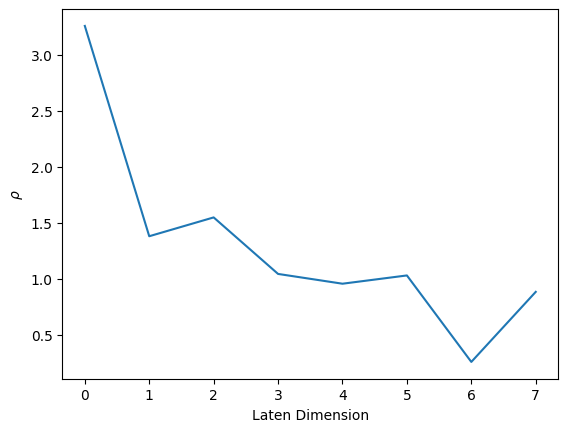

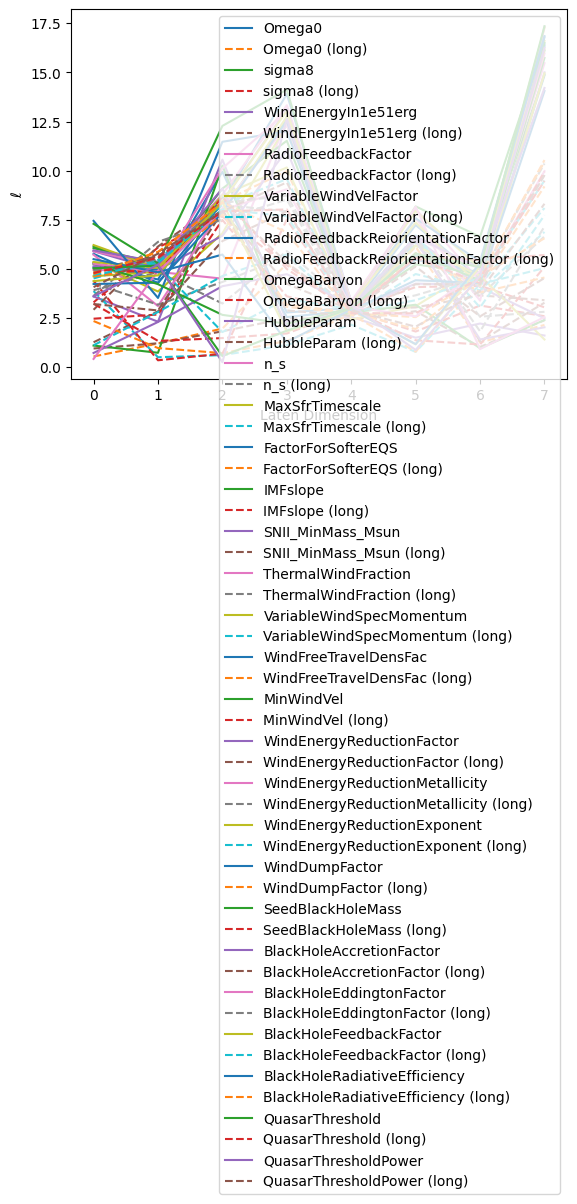

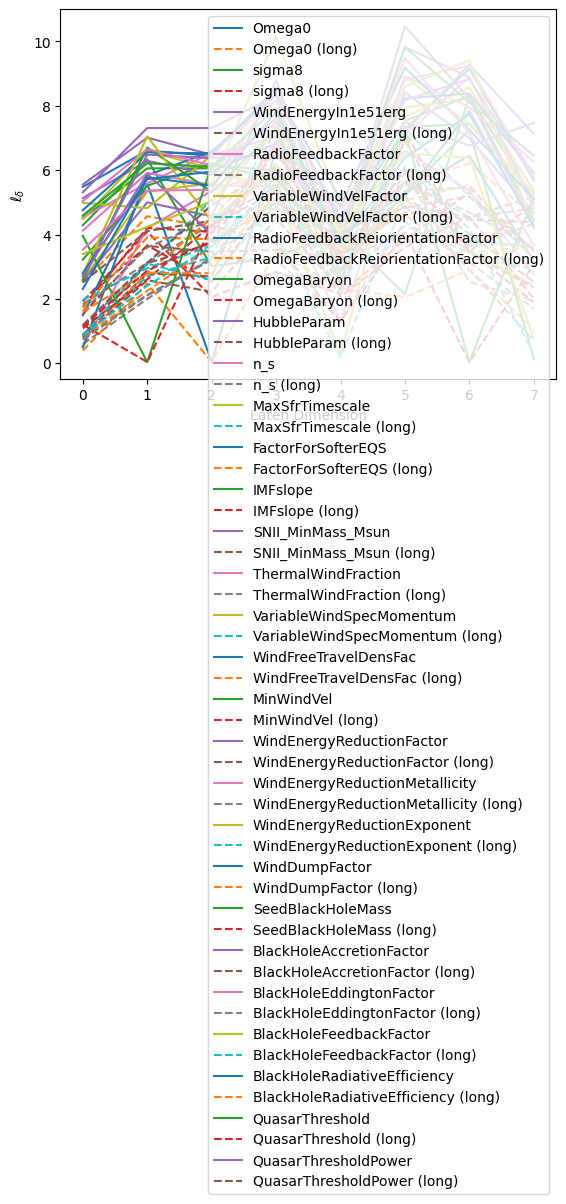

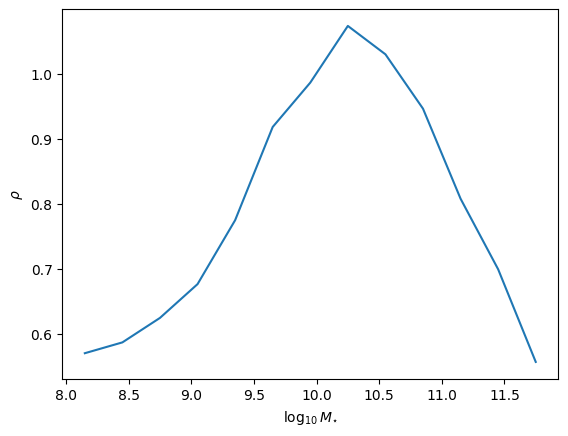

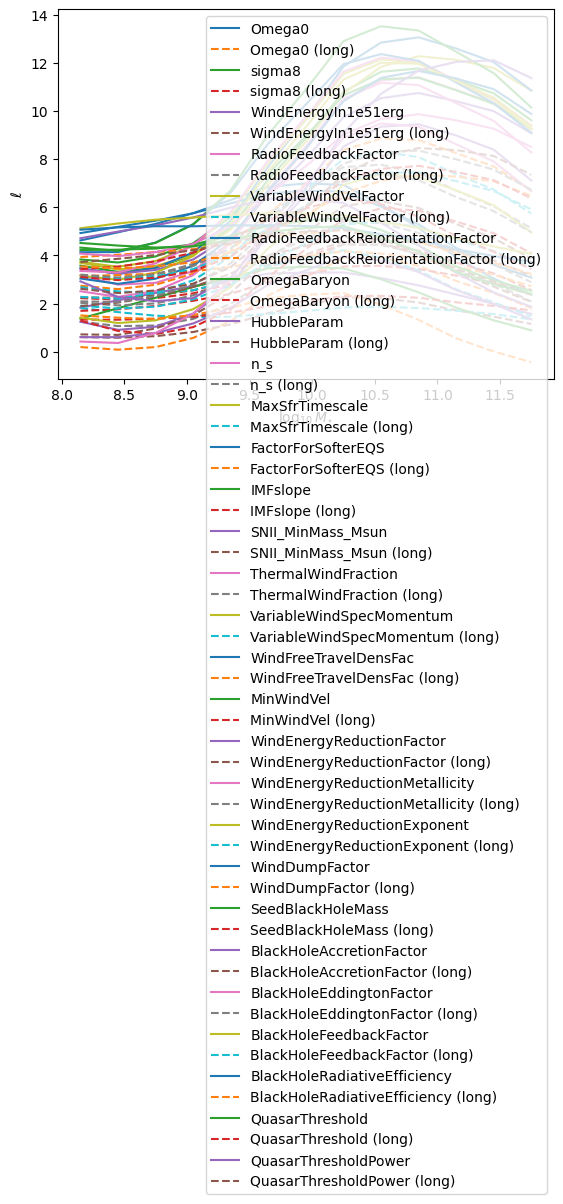

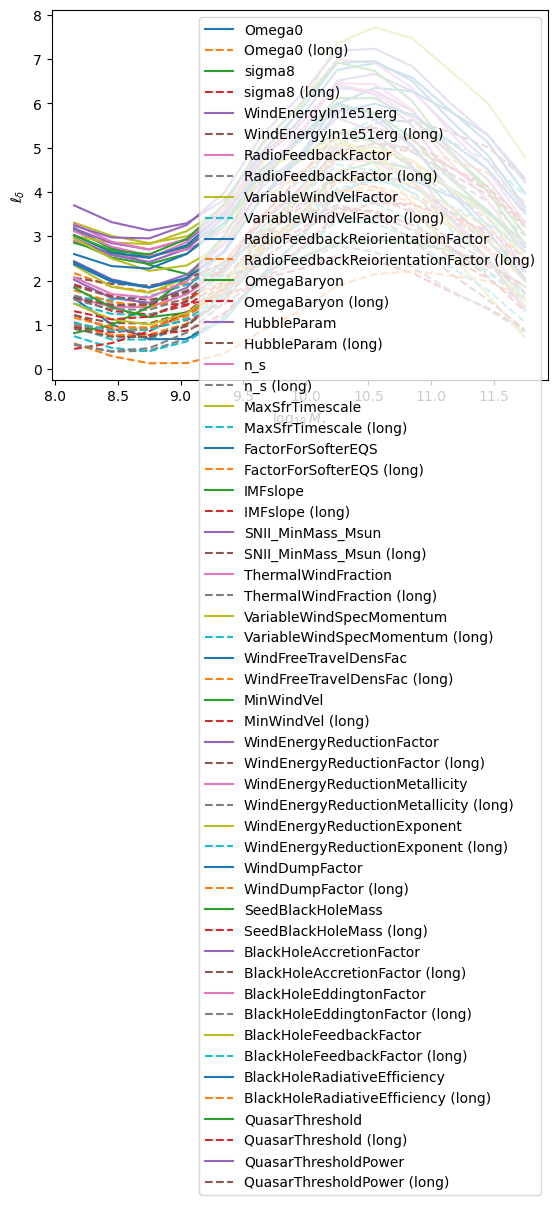

In [78]:
num_outputs = len(mf_gp.kernel.kernels)

# Extract the learned parameters
param_names = loader.param_names_[:28]
rho_values = []
lengthscale_values_long = []
lengthscale_delta_values_long = []
lengthscale_values_short = []
lengthscale_delta_values_short = []

for i in range(num_outputs):
    rho_values.append(mf_gp.kernel.kernels[i].rho.numpy()[0])
    lengthscale_values_long.append(mf_gp.kernel.kernels[i].kernel_L.kernels[0].lengthscales.numpy())
    lengthscale_delta_values_long.append(mf_gp.kernel.kernels[i].kernel_delta.kernels[0].lengthscales.numpy())
    lengthscale_values_short.append(mf_gp.kernel.kernels[i].kernel_L.kernels[1].lengthscales.numpy())
    lengthscale_delta_values_short.append(mf_gp.kernel.kernels[i].kernel_delta.kernels[1].lengthscales.numpy())

plt.plot(range(num_latents), rho_values)
plt.xlabel(r"Laten Dimension")
plt.ylabel(r"$\rho$")
plt.show()

for i,param_name in enumerate(param_names):
    plt.plot(range(num_latents), np.array(lengthscale_values_short)[:, i], label=param_name)
    plt.plot(range(num_latents), np.array(lengthscale_values_long)[:, i], ls='--', label=param_name + " (long)")
plt.xlabel(r"Laten Dimension")
plt.legend()
plt.ylabel(r"$\ell$")
plt.show()

for i,param_name in enumerate(param_names):
    plt.plot(range(num_latents), np.array(lengthscale_delta_values_short)[:, i], label=param_name)
    plt.plot(range(num_latents), np.array(lengthscale_delta_values_long)[:, i], ls='--', label=param_name + " (long)")
plt.xlabel(r"Laten Dimension")
plt.ylabel(r"$\ell_{\delta}$")
plt.legend()
plt.show()

# Projected rho values
projected_rho = mf_gp.kernel.W.numpy() @ np.array(rho_values)
plt.plot(loader.log10M, projected_rho[:, 0])
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$\rho$")
plt.show()

for i,param_name in enumerate(param_names):
    plt.plot(loader.log10M, mf_gp.kernel.W.numpy() @ np.array(lengthscale_values_short)[:, i], label=param_name)
    plt.plot(loader.log10M, mf_gp.kernel.W.numpy() @ np.array(lengthscale_values_long)[:, i], ls='--', label=param_name + " (long)")
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.legend()
plt.ylabel(r"$\ell$")
plt.show()

for i,param_name in enumerate(param_names):
    plt.plot(loader.log10M, mf_gp.kernel.W.numpy() @ np.array(lengthscale_delta_values_short)[:, i], label=param_name)
    plt.plot(loader.log10M, mf_gp.kernel.W.numpy() @ np.array(lengthscale_delta_values_long)[:, i], ls='--', label=param_name + " (long)")
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$\ell_{\delta}$")
plt.legend()
plt.show()


## Diagnosis

In [25]:
import numpy as np

def pca_cov(Y, K=None):
    # Y: (N,P), already standardized per bin across LF∪HF
    C = np.cov(Y, rowvar=False)
    w, U = np.linalg.eigh(C)               # ascending
    idx = np.argsort(w)[::-1]              # descending
    w, U = w[idx], U[:, idx]
    if K is not None:
        U = U[:, :K]
    return C, w, U

def subspace_principal_angles(Ua, Ub):  # Ua, Ub: (P,K) with orthonormal cols
    # cos(angles) = svd(Ua^T Ub)
    _, s, _ = np.linalg.svd(Ua.T @ Ub, full_matrices=False)
    s = np.clip(s, 0, 1)
    return np.arccos(s)  # radians

def cov_shape_distance(Ca, Cb):
    # Compare *shapes* (ignore overall scale): Frobenius dist on trace-normalized
    Ca = Ca / np.trace(Ca)
    Cb = Cb / np.trace(Cb)
    return np.linalg.norm(Ca - Cb, ord='fro')

# Example use:
# Y128_std, Y256_std, Y512_std: standardized with SAME (mu, sd) from LF∪HF combined
K = 6  # compare first ~half of P
C128, w128, U128 = pca_cov(loader.Y128, K)
C512, w512, U512 = pca_cov(loader.Y256, K)
angles = subspace_principal_angles(U128, U512)  # small angles = aligned
shape_d = cov_shape_distance(C128, C512)
print("principal angles (deg):", np.degrees(angles))
print("cov shape distance (Fro):", shape_d)

principal angles (deg): [ 1.12129503  1.81765629  2.49104073  3.34269088 11.187605   26.39477255]
cov shape distance (Fro): 0.11839799364328128


In [26]:
# After training:
W = mf_gp.kernel.W.numpy()            # (P, L)
Sigma_model = W @ W.T                 # (P, P) model-implied output cov (up to kernel scales)

# Data-driven:
C128, _, _ = pca_cov(loader.Y128[:, :13])        # empirical cov
C512, _, _ = pca_cov(loader.Y256[:, :13])

# Compare shapes to model:
def align_dist(C, S):
    Cn = C / np.trace(C); Sn = S / np.trace(S)
    return np.linalg.norm(Cn - Sn, 'fro')

print("dist(model, LF):", align_dist(C128, Sigma_model))
print("dist(model, HF):", align_dist(C512, Sigma_model))

dist(model, LF): 0.6223893475171793
dist(model, HF): 0.7164631952363936


In [27]:
mf_gp

name,class,transform,prior,trainable,shape,dtype,value
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_L.kernels[0].variance,Parameter,Softplus,,True,(),float64,2.81341
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_L.kernels[0].lengthscales,Parameter,Softplus,,True,"(28,)",float64,"[0.68033, 1.35622, 1.55579..."
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_L.kernels[1].variance,Parameter,Softplus,,True,(),float64,0.46823
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_L.kernels[1].lengthscales,Parameter,Softplus,,True,"(28,)",float64,"[6.60125, 9.23042, 8.21994..."
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_delta.kernels[0].variance,Parameter,Softplus,,True,(),float64,5.0068
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_delta.kernels[0].lengthscales,Parameter,Softplus,,True,"(28,)",float64,"[7.64511, 7.40559, 4.46322..."
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_delta.kernels[1].variance,Parameter,Softplus,,True,(),float64,0.02234
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_delta.kernels[1].lengthscales,Parameter,Softplus,,True,"(28,)",float64,"[5.72363, 6.01182, 3.75511..."
LatentMFCoregionalizationSVGP.kernel.kernels[0].rho,Parameter,Softplus,,True,"(1, 1)",float64,[[2.1002]]
LatentMFCoregionalizationSVGP.kernel.kernels[1].kernel_L.kernels[0].variance,Parameter,Softplus,,True,(),float64,0.21674
